## Define problem name here

In [43]:
import json 
import os
from matplotlib import pyplot as plt 

PROBLEM_NAME = "cfgpipe"

DPY_PATH = os.path.join("scb-problems", PROBLEM_NAME, "dpy_results")
dirs = sorted(os.listdir(DPY_PATH))

## Function Cyclomatic Complexity

In [44]:
# count the number of functions with CC greater or equal than this threshold
THRESHOLD = 11

fcc = []
for dir in dirs: 
    # open the json 
    try: 
        with open(os.path.join(DPY_PATH, dir, f"{dir}_function_metrics.json"), 'r') as data: 
            data_json = json.load(data) 
            complex_funcs = [x for x in data_json if x["CC"] >= THRESHOLD]
            fcc.append(len(complex_funcs))
    except FileNotFoundError:
        fcc.append(0)

print(fcc)

[1, 1, 2, 5, 6]


## Magic number

In [45]:
mn = [] 
for dir in dirs: 
    try: 
        with open(os.path.join(DPY_PATH, dir, f"{dir}_implementation_smells.json"), 'r') as data: 
            data_json = json.load(data) 
            mns = [x for x in data_json if x["Smell"] == "Magic number"]
            mn.append(len(mns))
    except FileNotFoundError:
        mn.append(0)

print(mn)


[0, 2, 3, 9, 15]


## Class LCOM

In [46]:
lcom = [] 
for dir in dirs: 
    try: 
        with open(os.path.join(DPY_PATH, dir, f"{dir}_class_module_metrics.json"), 'r') as data: 
            data_json = json.load(data) 
            lcoms = [x for x in data_json if x["LCOM"]>=1]
            lcom.append(len(lcoms))
    except FileNotFoundError:
        lcom.append(0)

print(lcom)

[0, 0, 0, 0, 0]


## Fan out

In [47]:
fanout = [] 
for dir in dirs: 
    try: 
        with open(os.path.join(DPY_PATH, dir, f"{dir}_class_module_metrics.json"), 'r') as data: 
            data_json = json.load(data) 
            fanouts = [x for x in data_json if x["Fan-Out"]>=7]
            fanout.append(len(fanouts))
    except FileNotFoundError:
        fanout.append(0)

print(fanout)

[0, 0, 0, 0, 0]


## Modularisation warnings

In [48]:
mw = [] 
for dir in dirs: 
    try: 
        with open(os.path.join(DPY_PATH, dir, f"{dir}_design_smells.json"), 'r') as data: 
            data_json = json.load(data) 
            mws = [x for x in data_json if x["Smell"] in ["Insufficient modularization", "Hub-like modularization"]]
            mw.append(len(mws))
    except FileNotFoundError:
        mw.append(0)

print(mw)

[0, 0, 0, 1, 1]


## Feature envy

In [50]:
fe = [] 
for dir in dirs: 
    try: 
        with open(os.path.join(DPY_PATH, dir, f"{dir}_design_smells.json"), 'r') as data: 
            data_json = json.load(data) 
            fes = [x for x in data_json if x["Smell"] == "Feature envy"]
            fe.append(len(fes))
    except FileNotFoundError:
        fe.append(0)

print(fe)

[0, 0, 0, 0, 0]


## Deficient encapsulation (Intrusive coupling)

In [51]:
de = [] 
for dir in dirs: 
    try: 
        with open(os.path.join(DPY_PATH, dir, f"{dir}_design_smells.json"), 'r') as data: 
            data_json = json.load(data) 
            des = [x for x in data_json if x["Smell"] == "Deficient encapsulation"]
            de.append(len(des))
    except FileNotFoundError:
        de.append(0)

print(de)

[0, 0, 0, 1, 1]


# Plot

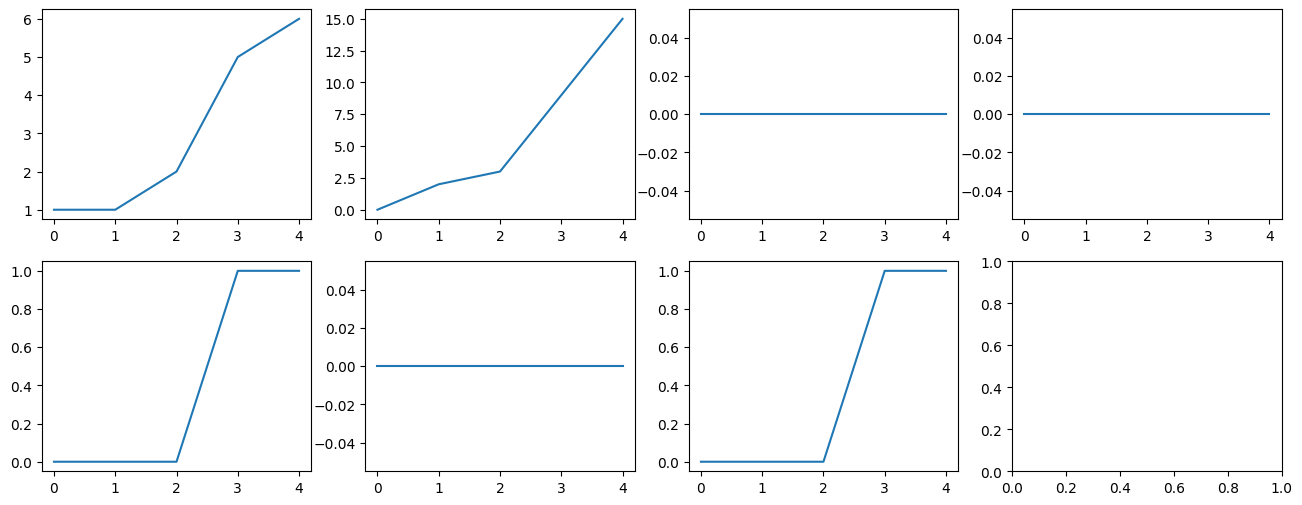

In [52]:
metrics = [fcc, mn, lcom, fanout, mw, fe, de]
fig, ax = plt.subplots(2,4,figsize=(16,6)) 
ax = ax.flatten() 
for i, m in enumerate(metrics): 
    ax[i].plot(m) 

plt.show()